In [1]:
import os
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

In [ ]:
data_dir = "../data/faces/lfw_funneled" 
batch_size = 64
image_size = 64
latent_dim = 128
epochs = 100
lr = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cpu


In [3]:
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
])

In [4]:
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print(f"Загружено {len(dataset)} изображений")

Загружено 13233 изображений


In [5]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  # 64 -> 32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  # 32 -> 16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # 16 -> 8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),  # 8 -> 4
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

In [6]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 4 -> 8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 8 -> 16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 16 -> 32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),     # 32 -> 64
            nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 4, 4)
        return self.deconv(x)


In [7]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar

In [8]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

In [9]:
vae = VAE(latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=lr)
loss_history = []

In [10]:
vae.train()
for epoch in range(1, epochs + 1):
    total_loss = 0
    for imgs, _ in dataloader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = vae(imgs)
        loss = vae_loss(recon, imgs, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataset)
    loss_history.append(avg_loss)
    print(f"Epoch [{epoch}/{epochs}] — Loss: {avg_loss:.2f}")

Epoch [1/25] — Loss: 573.62
Epoch [2/25] — Loss: 358.74
Epoch [3/25] — Loss: 311.99
Epoch [4/25] — Loss: 291.36
Epoch [5/25] — Loss: 274.99
Epoch [6/25] — Loss: 258.52
Epoch [7/25] — Loss: 250.24
Epoch [8/25] — Loss: 243.39
Epoch [9/25] — Loss: 239.51
Epoch [10/25] — Loss: 235.91
Epoch [11/25] — Loss: 233.29
Epoch [12/25] — Loss: 231.50
Epoch [13/25] — Loss: 229.51
Epoch [14/25] — Loss: 227.24
Epoch [15/25] — Loss: 226.38
Epoch [16/25] — Loss: 225.04
Epoch [17/25] — Loss: 223.72
Epoch [18/25] — Loss: 223.10
Epoch [19/25] — Loss: 221.94
Epoch [20/25] — Loss: 221.18
Epoch [21/25] — Loss: 220.49
Epoch [22/25] — Loss: 219.95
Epoch [23/25] — Loss: 219.03
Epoch [24/25] — Loss: 218.16
Epoch [25/25] — Loss: 218.07


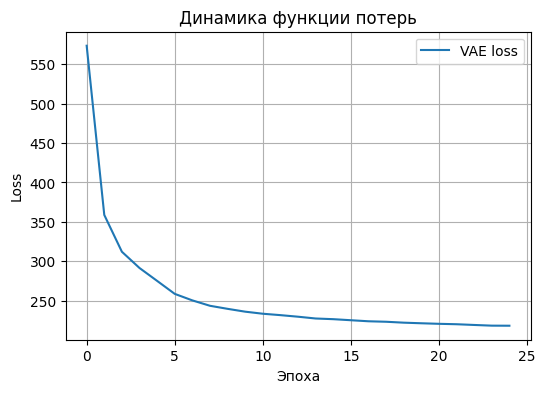

In [11]:
plt.figure(figsize=(6,4))
plt.plot(loss_history, label="VAE loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Динамика функции потерь")
plt.legend()
plt.grid()
plt.show()

Сохранено: reconstruction.png


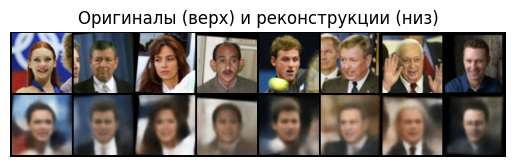

In [12]:
vae.eval()
with torch.no_grad():
    imgs, _ = next(iter(dataloader))
    imgs = imgs.to(device)
    recon, _, _ = vae(imgs)
    comparison = torch.cat([imgs[:8], recon[:8]])
    utils.save_image(comparison.cpu(), "reconstruction.png", nrow=8)
    print("Сохранено: reconstruction.png")

plt.imshow(np.transpose(utils.make_grid(comparison.cpu(), nrow=8), (1,2,0)))
plt.axis('off')
plt.title("Оригиналы (верх) и реконструкции (низ)")
plt.show()

Сохранено: generated_faces.png


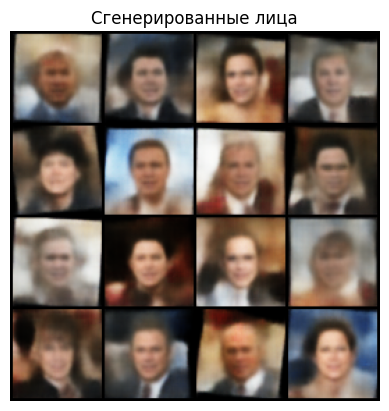

In [13]:
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = vae.decoder(z)
    utils.save_image(samples.cpu(), "generated_faces.png", nrow=4)
    print("Сохранено: generated_faces.png")

plt.imshow(np.transpose(utils.make_grid(samples.cpu(), nrow=4), (1,2,0)))
plt.axis('off')
plt.title("Сгенерированные лица")
plt.show()

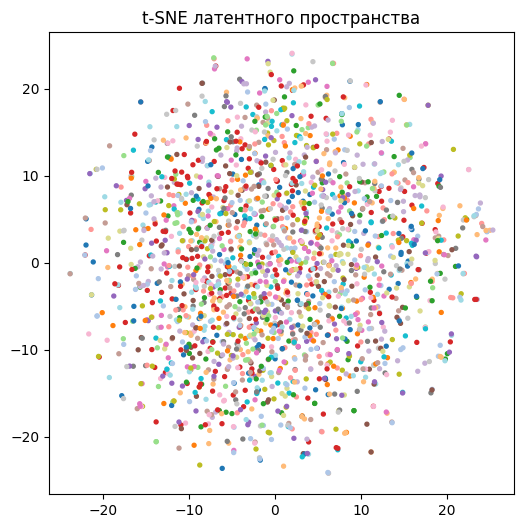

In [14]:
vae.eval()
latents = []
labels = []

with torch.no_grad():
    for imgs, lbl in dataloader:
        imgs = imgs.to(device)
        mu, _ = vae.encoder(imgs)
        latents.append(mu.cpu().numpy())
        labels.extend(lbl.numpy())
        if len(latents) * batch_size > 2000:  # ограничим выборку для скорости
            break

latents = np.concatenate(latents, axis=0)
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latents)

plt.figure(figsize=(6,6))
plt.scatter(latent_2d[:,0], latent_2d[:,1], c=labels, cmap='tab20', s=8)
plt.title("t-SNE латентного пространства")
plt.show()